# engenharia de features — engenharia de features

Três features derivadas candidatas (identificadas na EDA da EDA),
testadas **isoladamente** (nunca em lote) contra o baseline de Gradient
Boosting da baselines, medindo o efeito na validação antes de qualquer
decisão:

- `charges_per_tenure` = `TotalCharges / (tenure + 1)` — gasto médio
  mensal implícito.
- `n_servicos_adicionais` = contagem de serviços extras contratados
  (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
  StreamingTV, StreamingMovies).
- `tenure_bucket` = faixas de tenure (0-12, 12-24, 24-48, 48-73 meses),
  mantendo a versão numérica de `tenure` também.

Os hiperparâmetros do Gradient Boosting ficam **fixos** (os mesmos do
baseline da baselines) para isolar o efeito das features — misturar tuning de
hiperparâmetro com engenharia de features tornaria impossível saber qual
dos dois está causando qualquer mudança observada.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn_telecom.checkpointing import load_all_metadata

sns.set_theme(style="whitegrid")


## 1. Efeito isolado de cada feature (validação)

In [2]:
efeito = pd.read_csv(ROOT / "reports/tables/engenharia_features_efeito.csv")
efeito


,variante,features,ks_val,ganho_sobre_baseline
0,baseline (sem features derivadas),(),0.551005,0.000000
1,+ charges_per_tenure,"('charges_per_tenure',)",0.555641,0.004637
2,+ n_servicos_adicionais,"('n_servicos_adicionais',)",0.547141,-0.003864
3,+ tenure_bucket,"('tenure_bucket',)",0.551005,0.000000
4,"combinacao vencedoras ('charges_per_tenure',)","('charges_per_tenure',)",0.555641,0.004637


/sessions/rcw-0113vrfemyrixwwnuzv7au4n/tmp/ipykernel_9/2140762831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=efeito, x="variante", y="ganho_sobre_baseline", ax=ax, palette=cores)


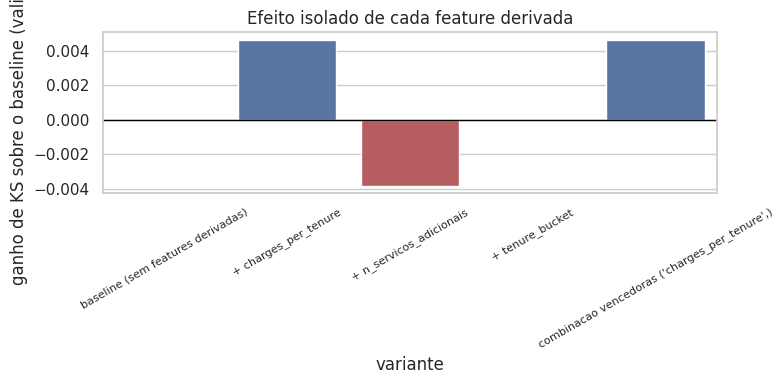

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
cores = ["#4C72B0" if g >= 0 else "#C44E52" for g in efeito["ganho_sobre_baseline"]]
sns.barplot(data=efeito, x="variante", y="ganho_sobre_baseline", ax=ax, palette=cores)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("ganho de KS sobre o baseline (validação)")
ax.set_title("Efeito isolado de cada feature derivada")
ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/engenharia_features_efeito.png", dpi=120)
plt.show()


## 2. Decisão e resultado honesto no teste

Só `charges_per_tenure` teve ganho positivo isolado na validação
(+0.0046) — `n_servicos_adicionais` piorou e `tenure_bucket` não mudou
nada (a informação de faixa já está implícita em `tenure` numérico para um
modelo de árvore). A combinação testada foi só a feature vencedora.

**Mas o ganho não se confirmou no teste**: o modelo com `charges_per_tenure`
teve KS=0.516 no teste, **abaixo** do baseline puro da baselines (KS=0.524).
Isso é o mesmo padrão de ruído de validação já visto na busca de hiperparâmetros — um ganho
pequeno (+0.0046) numa única validação não é confiável o suficiente para
garantir melhora real fora dela.

In [4]:
resumo = load_all_metadata(ROOT / "results")
cols_mostrar = ["model_id", "metrics.ks", "metrics.auroc", "metrics.recall", "metrics.precision"]
cols_existentes = [c for c in cols_mostrar if c in resumo.columns]
tabela = resumo[cols_existentes].sort_values("metrics.ks", ascending=False).reset_index(drop=True)
tabela


,model_id,metrics.ks,metrics.auroc,metrics.recall,metrics.precision
0,gb_churn_baseline_oversample,0.524183,0.831954,0.743590,0.532110
1,xgb_churn_baseline_oversample,0.519855,0.831416,0.752137,0.528529
2,gb_churn_features_charges_per_tenure,0.516083,0.831512,0.747863,0.529501
3,gb_churn_baseline_classweight,0.512136,0.831246,0.758547,0.512266
4,mlp_churn_baseline_oversample,0.511046,0.829421,0.767094,0.493132
5,mlp_churn_optuna_leva1,0.510758,0.816685,0.724359,0.544141
6,gb_churn_optuna_leva1,0.510391,0.835575,0.756410,0.513043
7,xgb_churn_baseline_scaleposweight,0.509767,0.833499,0.767094,0.515805


## 3. Resumo e próximos passos

- Nenhuma das três features derivadas trouxe ganho real e confiável sobre
  o baseline da baselines — resultado negativo, documentado honestamente em
  vez de forçar uma narrativa de melhoria.
- O baseline `gb_churn_baseline_oversample` da baselines (KS=0.524 no teste)
  continua sendo a melhor referência do projeto até aqui.
- Padrão que se repete entre busca de hiperparâmetros (hiperparâmetros) e engenharia de features (features):
  pequenos ganhos vistos na validação não generalizam para o teste — sinal
  de que o espaço de melhoria incremental neste dataset, com esta
  arquitetura, pode já estar perto do limite para ajustes finos.
- Próximo passo: investigar os modelos avançados (STab, TabPFNv2, KAN,
  TabKAN, Mitra), já que MLP e Gradient Boosting deram resultado estável e
  as duas levas de refinamento (busca de hiperparâmetros e engenharia de features) não encontraram mais
  ganho incremental fácil.
